# Exploratory Data Analysis: Malaysian Public Transport Ridership

## Objective

Explore the quality, temporal patterns, anomalies, and forecastability of daily
ridership data, using `rail_mrt_kajang` as the initial prediction target.

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import holidays

DATA_PATH = "../data/ridership_headline.parquet"

df = pd.read_parquet(DATA_PATH)

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(by='date').set_index('date')

print(df.shape)
print(df.head())
print(df.describe())
print(df.dtypes)

(2738, 14)
            bus_rkl  bus_rkn  bus_rpn  rail_lrt_ampang  rail_mrt_kajang  \
date                                                                      
2019-01-01     <NA>     <NA>     <NA>           113357           114173   
2019-01-02     <NA>     <NA>     <NA>           182715           169316   
2019-01-03     <NA>     <NA>     <NA>           187904           175304   
2019-01-04     <NA>     <NA>     <NA>           198420           187891   
2019-01-05     <NA>     <NA>     <NA>           120773           112660   

            rail_lrt_kj  rail_monorail  rail_mrt_pjy  rail_lrt_shah_alam  \
date                                                                       
2019-01-01       139634          35804          <NA>                <NA>   
2019-01-02       274224          31859          <NA>                <NA>   
2019-01-03       286469          31893          <NA>                <NA>   
2019-01-04       304755          34121          <NA>                <NA>   
2019-01

In [19]:
expected_date = pd.date_range(df.index.min(), df.index.max(), freq='D')

missing_dates = expected_date.difference(df.index)

print(f"Missing dates: {len(missing_dates)}")

Missing dates: 0


### Data availability observation

Missing values are concentrated at the beginning of certain service histories.
They are likely structural—for example, services that had not launched or data
that was not yet reported. These values should not automatically be imputed
with zero.

In [20]:
quality = pd.DataFrame({
    'dtype': df.dtypes,
    'missing_count': df.isna().sum(),
    'missing_pct': df.isna().mean().mul(100),
    'zero_count': (df == 0).sum(),
    'negative_count': (df < 0).sum(),
    'first_valid': df.apply(pd.Series.first_valid_index),
    'last_valid': df.apply(pd.Series.last_valid_index),
    'unique_values': df.nunique(),
})

display(quality.sort_values('missing_pct', ascending=False))


,dtype,missing_count,missing_pct,zero_count,negative_count,first_valid,last_valid,unique_values
rail_lrt_shah_alam,Int64,2678,97.808619,58,0,2026-04-01,2026-06-30,3
rail_komuter,Int64,1713,62.563915,0,0,2023-09-10,2026-06-30,1000
rail_tebrau,Int64,1265,46.201607,0,0,2022-06-19,2026-06-30,1170
rail_mrt_pjy,Int64,1262,46.092038,0,0,2022-06-16,2026-06-30,1469
bus_rkl,Int64,1096,40.029218,0,0,2022-01-01,2026-06-30,1634
bus_rkn,Int64,1096,40.029218,198,0,2022-01-01,2026-06-30,969
bus_rpn,Int64,1096,40.029218,0,0,2022-01-01,2026-06-30,1586
rail_komuter_utara,Int64,653,23.849525,0,0,2020-10-15,2026-06-30,1975
rail_intercity,Int64,653,23.849525,0,0,2020-10-15,2026-06-30,1762
rail_ets,Int64,653,23.849525,0,0,2020-10-15,2026-06-30,1871


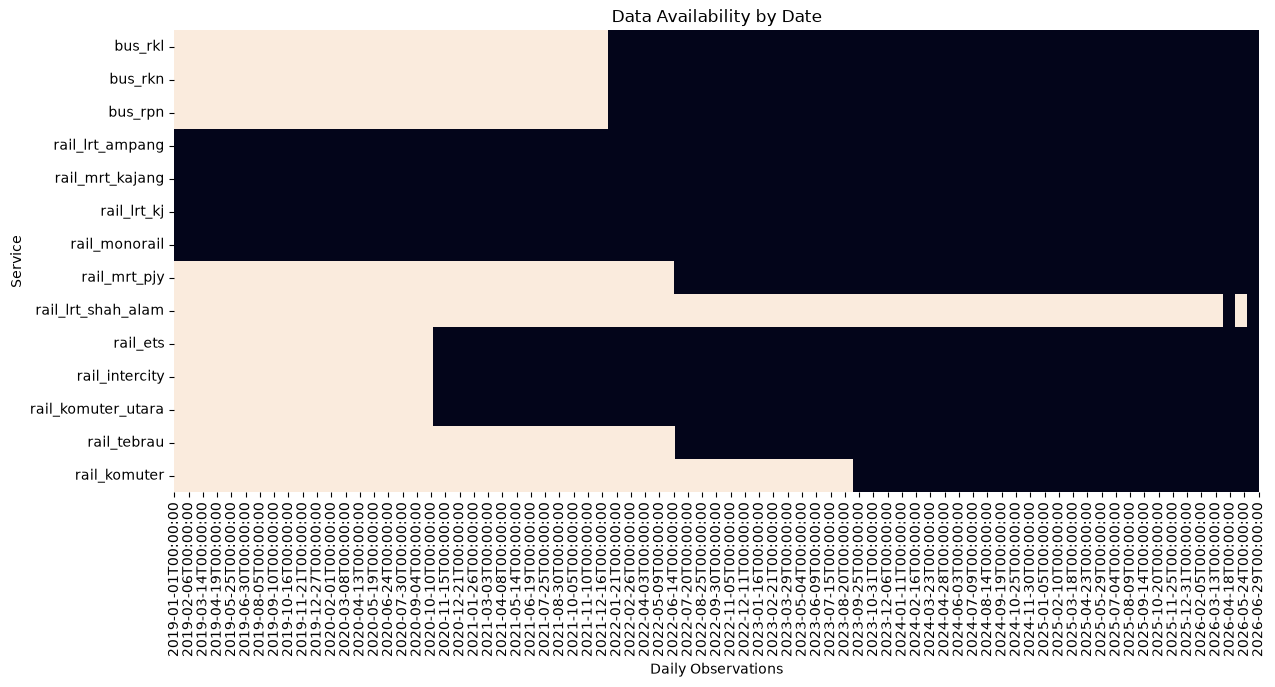

In [21]:
plt.figure(figsize=(14, 6))
sns.heatmap(df.isna().T, cbar=False, yticklabels=True)
plt.title("Data Availability by Date")
plt.xlabel("Daily Observations")
plt.ylabel("Service")
plt.show()

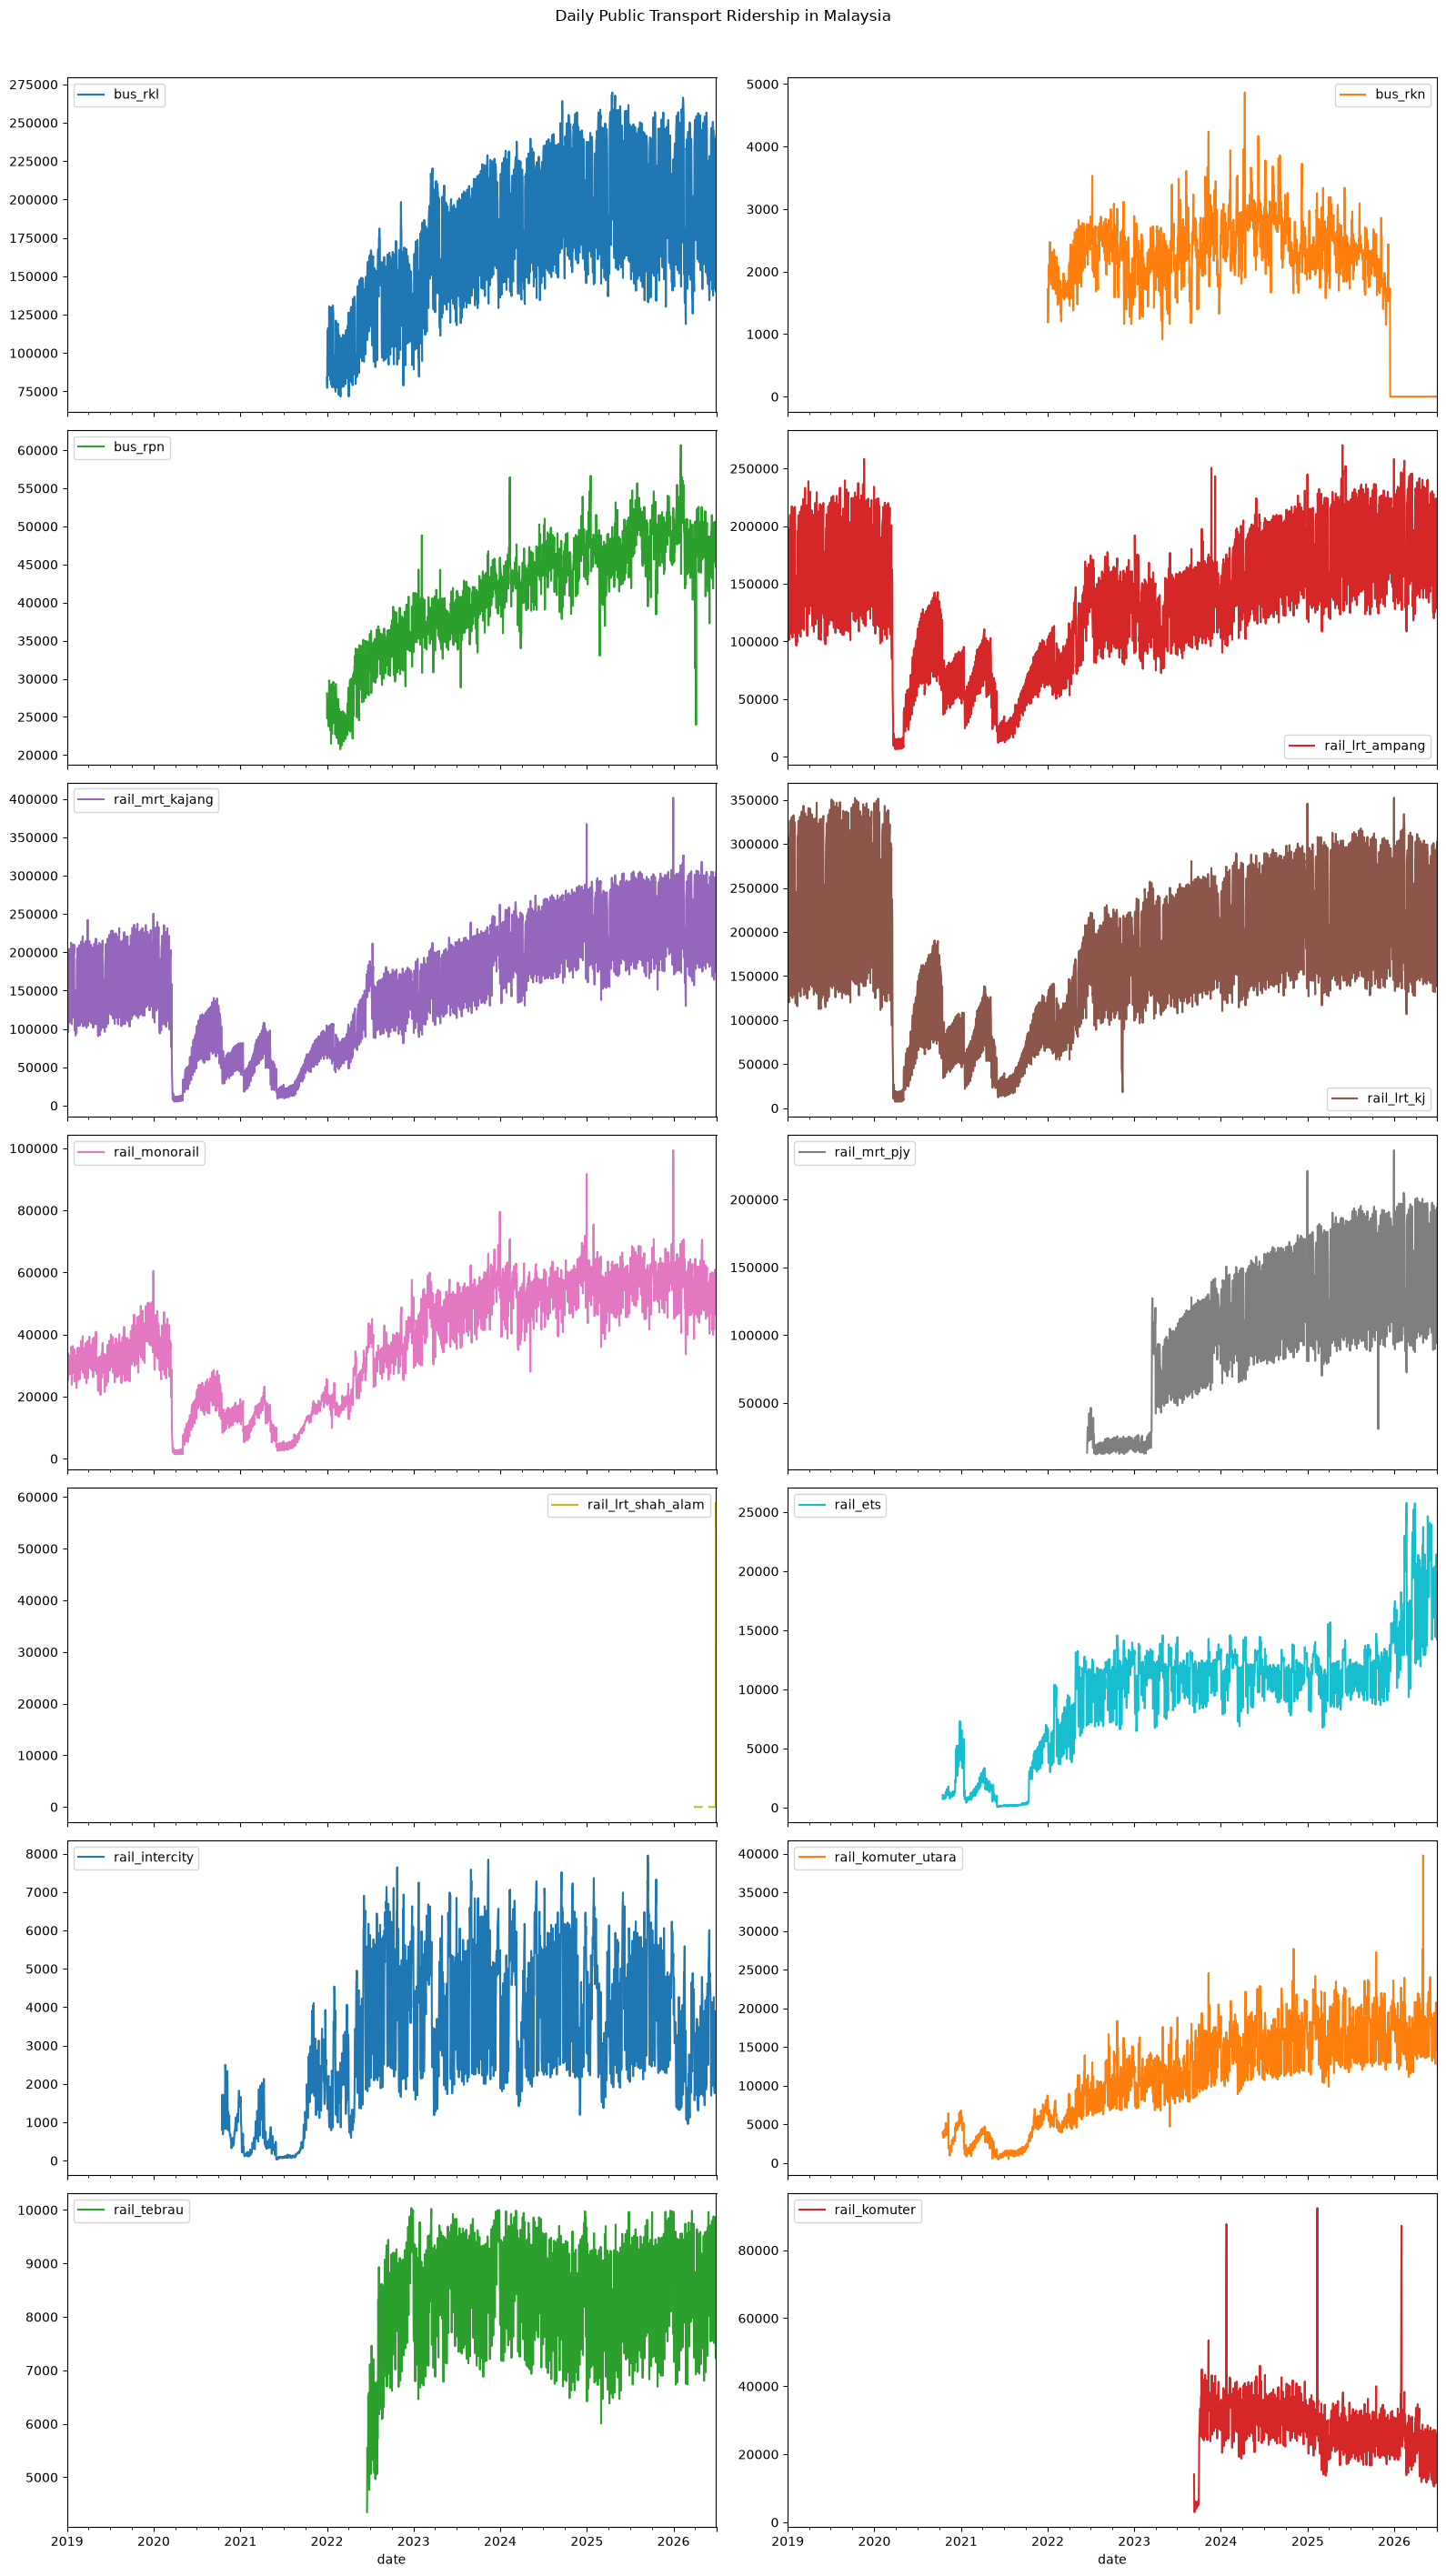

In [22]:
df.plot(
    subplots=True,
    figsize=(16, 28),
    sharex=True,
    layout=(-1, 2),
    legend=True
)

plt.suptitle("Daily Public Transport Ridership in Malaysia", y=1.01)
plt.tight_layout()
plt.show()

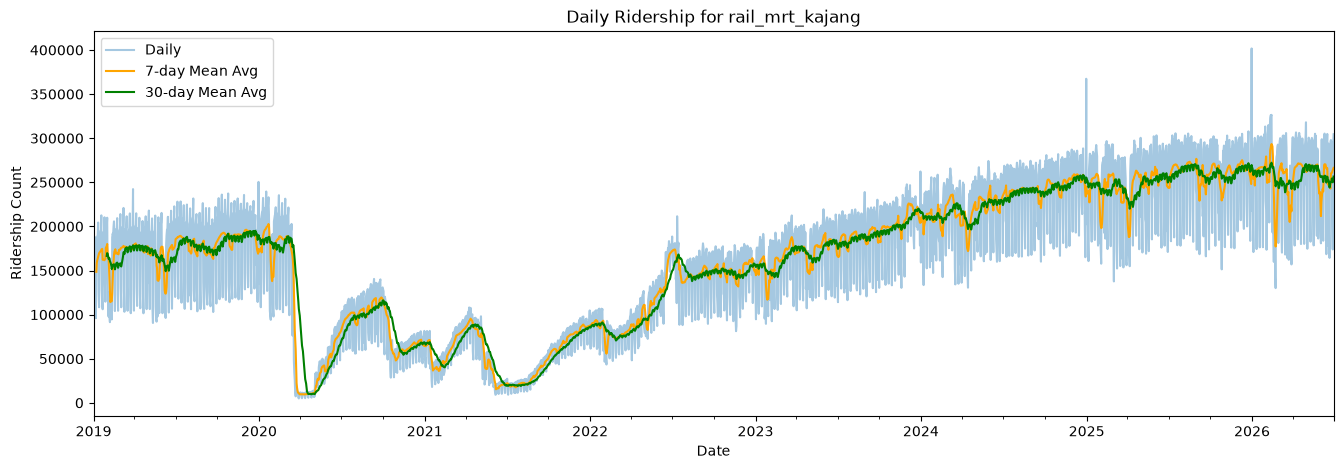

In [23]:
target = "rail_mrt_kajang"

ax = df[target].plot(figsize=(16, 5), alpha=0.4, label="Daily")
df[target].rolling(7).mean().plot(ax=ax, label="7-day Mean Avg", color="orange")
df[target].rolling(30).mean().plot(ax=ax, label="30-day Mean Avg", color="green")

ax.set(
    title=f"Daily Ridership for {target}",
    xlabel="Date",
    ylabel="Ridership Count"
)

ax.legend()
plt.show()

In [24]:
eda = df.copy()

eda['year'] = eda.index.year
eda['month'] = eda.index.month
eda['day_of_week'] = eda.index.day_name()
eda['is_weekend'] = eda.index.dayofweek >= 5

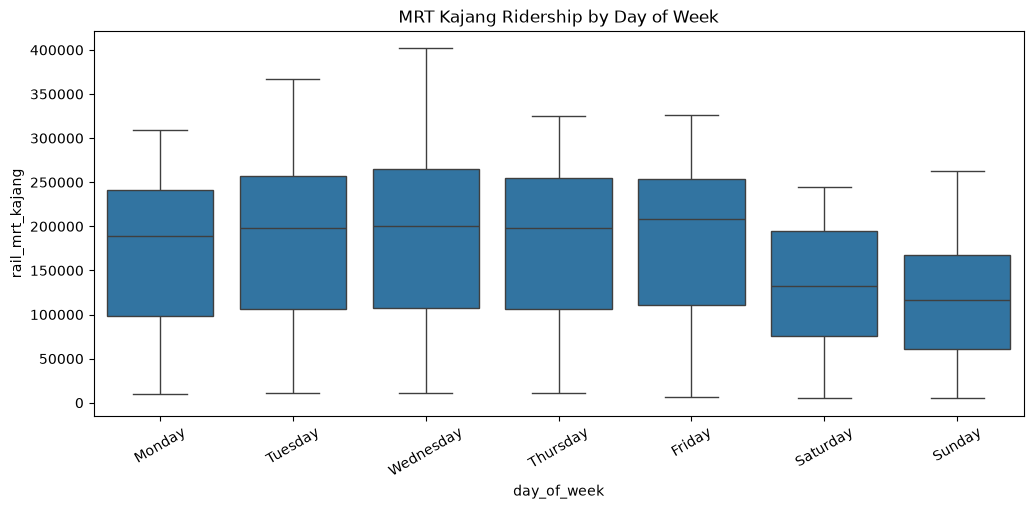

In [25]:
weekday_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday"
]

plt.figure(figsize=(12, 5))
sns.boxplot(
    data=eda,
    x="day_of_week",
    y=target,
    order=weekday_order,
    showfliers=False
)
plt.xticks(rotation=30)
plt.title("MRT Kajang Ridership by Day of Week")
plt.show()

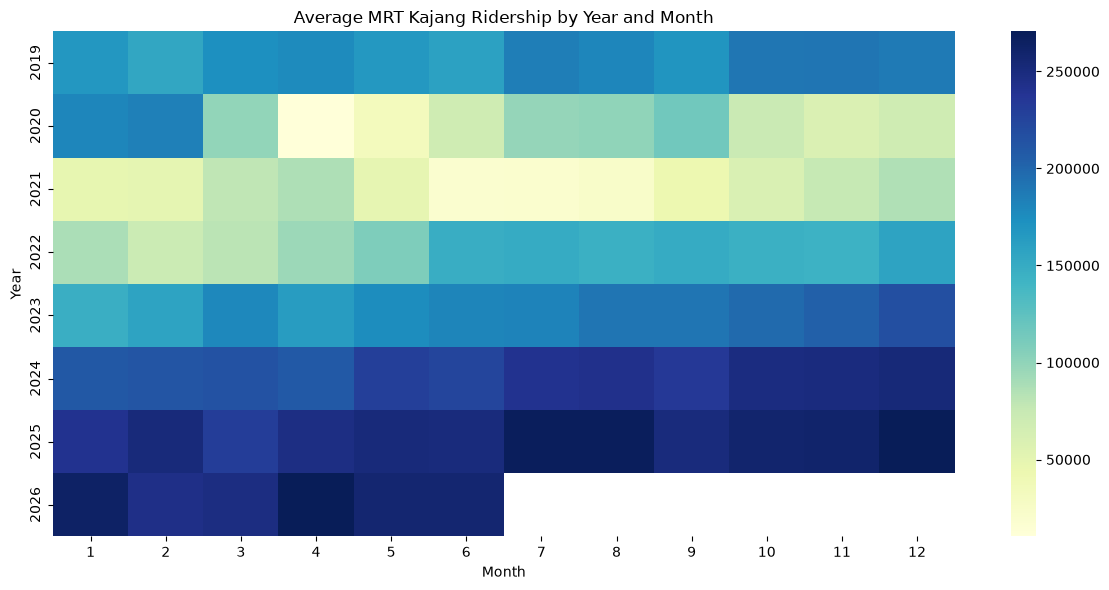

In [26]:
monthly = (
    eda.groupby(["year", "month"])[target]
    .mean()
    .unstack()
    .astype("float64")
)

plt.figure(figsize=(12, 6))

sns.heatmap(
    monthly,
    cmap="YlGnBu",
    annot=False,
    mask=monthly.isna()
)

plt.title("Average MRT Kajang Ridership by Year and Month")
plt.xlabel("Month")
plt.ylabel("Year")
plt.tight_layout()
plt.show()

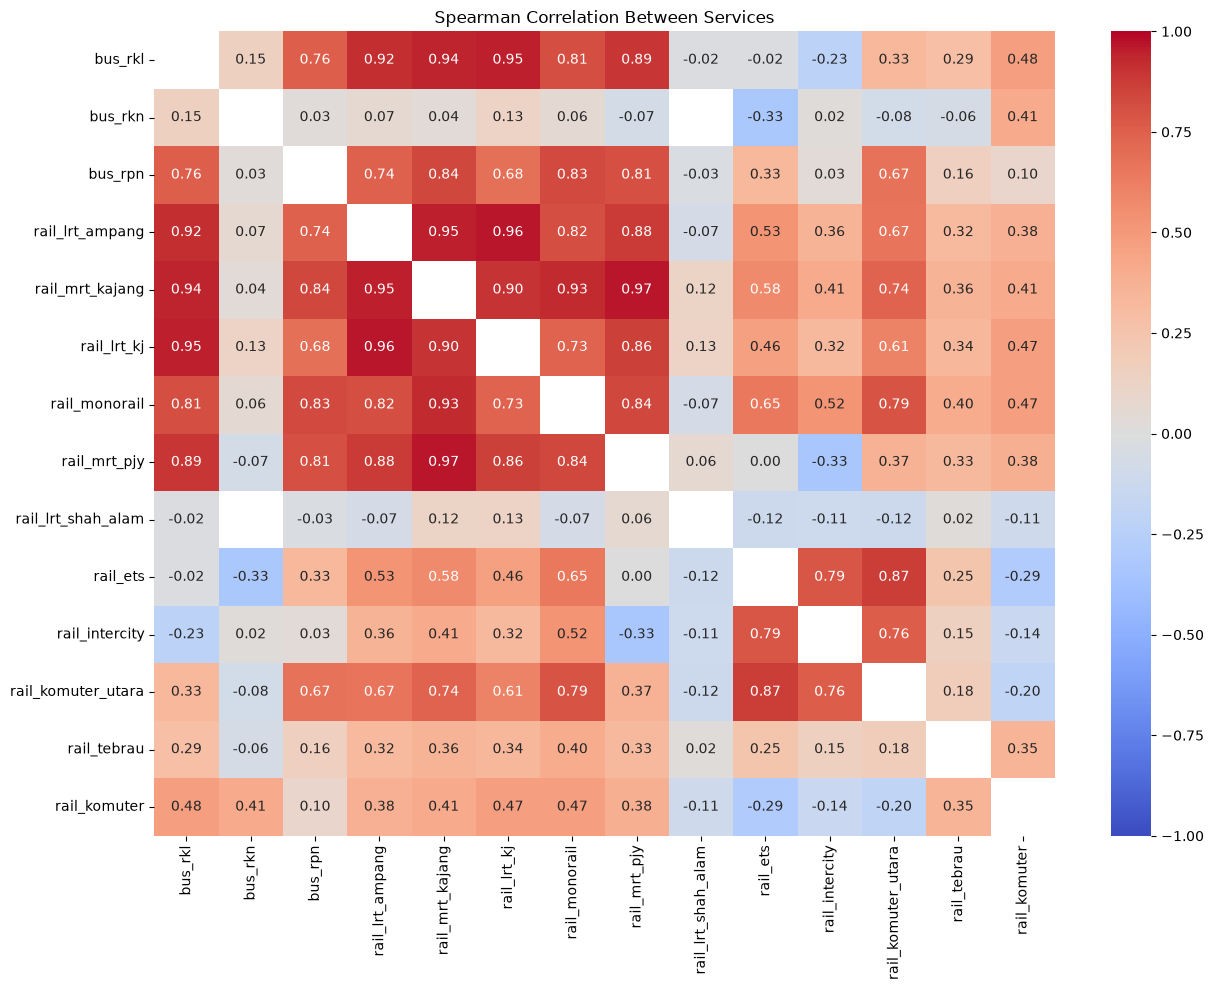

In [27]:
corr = df.corr(method="spearman", min_periods=30)

# Hide the diagonal
mask = np.eye(len(corr), dtype=bool)

plt.figure(figsize=(13, 10))
sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f"
)

plt.title("Spearman Correlation Between Services")
plt.tight_layout()
plt.show()

In [28]:
daily_change = df[target].pct_change(fill_method=None)

largest_drops = daily_change.nsmallest(10)
largest_increases = daily_change.nlargest(10)

display(pd.DataFrame({
    "ridership": df.loc[largest_drops.index, target],
    "percentage_change": largest_drops.mul(100)
}))

display(pd.DataFrame({
    "ridership": df.loc[largest_increases.index, target],
    "percentage_change": largest_increases.mul(100)
}))

,ridership,percentage_change
date,,
2020-03-18,47917,-65.794339
2021-06-01,18177,-62.371913
2021-05-13,20743,-59.960236
2021-07-03,11915,-56.300888
2020-03-21,11377,-55.522108
2020-03-14,93413,-53.939953
2021-01-13,38866,-52.354917
2020-05-01,6656,-51.87622
2021-07-20,11081,-51.781907


,ridership,percentage_change
date,,
2020-05-04,32976,355.847387
2021-05-24,53591,166.701503
2021-01-18,44509,147.933378
2020-10-19,70699,147.692954
2021-06-21,24584,140.218878
2021-07-05,21214,130.111726
2021-06-28,25527,129.70395
2021-01-25,48229,129.214391
2021-06-14,22976,129.141318


In [29]:
lag_correlations = pd.Series({
    f"lag_{lag}": df[target].corr(df[target].shift(lag))
    for lag in [1, 2, 3, 7, 14, 28, 30, 365]
})

display(lag_correlations.sort_values(ascending=False))

lag_7      0.946093
lag_14     0.937539
lag_28     0.914267
lag_1      0.882505
lag_2      0.782507
lag_3      0.763389
lag_30     0.741018
lag_365    0.547074
dtype: float64

## Malaysian Public Holiday Features

Rapid KL services operate across Kuala Lumpur, Selangor, and Putrajaya. Malaysia has both federal and state-specific holidays, so separate regional indicators are retained alongside one combined feature. Observed or replacement holidays are included.

These calendar features are known ahead of most forecasts and can therefore be used without target leakage. Exceptional holidays announced at short notice should be verified against official government gazettes.

In [30]:
years = range(eda.index.min().year, eda.index.max().year + 1)

holiday_calendars = {
    "kul": holidays.country_holidays("MY", subdiv="KUL", years=years, observed=True),
    "sgr": holidays.country_holidays("MY", subdiv="SGR", years=years, observed=True),
    "pjy": holidays.country_holidays("MY", subdiv="PJY", years=years, observed=True),
}

dates = pd.Series(eda.index.date, index=eda.index)

for region, calendar in holiday_calendars.items():
    eda[f"is_holiday_{region}"] = dates.isin(calendar).astype("int8")

regional_holiday_columns = [
    "is_holiday_kul",
    "is_holiday_sgr",
    "is_holiday_pjy",
]

eda["is_public_holiday"] = (
    eda[regional_holiday_columns].max(axis=1).astype("int8")
)

def get_holiday_names(date):
    names = {
        calendar.get(date)
        for calendar in holiday_calendars.values()
        if calendar.get(date) is not None
    }
    return " | ".join(sorted(names)) if names else None

eda["holiday_name"] = dates.map(get_holiday_names)

holiday = eda["is_public_holiday"].astype(bool)
eda["is_day_before_holiday"] = holiday.shift(-1, fill_value=False).astype("int8")
eda["is_day_after_holiday"] = holiday.shift(1, fill_value=False).astype("int8")

display(
    eda.loc[
        eda["is_public_holiday"].eq(1),
        ["holiday_name", *regional_holiday_columns, target],
    ].head(20)
)

,holiday_name,is_holiday_kul,is_holiday_sgr,is_holiday_pjy,rail_mrt_kajang
date,,,,,
2019-01-01,Tahun Baharu,1,1,1,114173
2019-01-21,Hari Thaipusam,1,1,1,106077
2019-02-01,Hari Wilayah Persekutuan,1,0,1,134808
2019-02-05,Tahun Baharu Cina,1,1,1,98115
2019-02-06,Tahun Baharu Cina (Hari Kedua),1,1,1,91478
2019-05-01,Hari Pekerja,1,1,1,135733
2019-05-19,Hari Wesak,1,1,1,94901
2019-05-20,Cuti Hari Wesak,1,1,1,92033
2019-05-22,Hari Nuzul Al-Quran,1,1,1,97824


,count,mean,median,std
is_public_holiday,,,,
0,2566,167840.369836,178185.0,82865.723084
1,172,125522.261628,119029.5,63269.683608


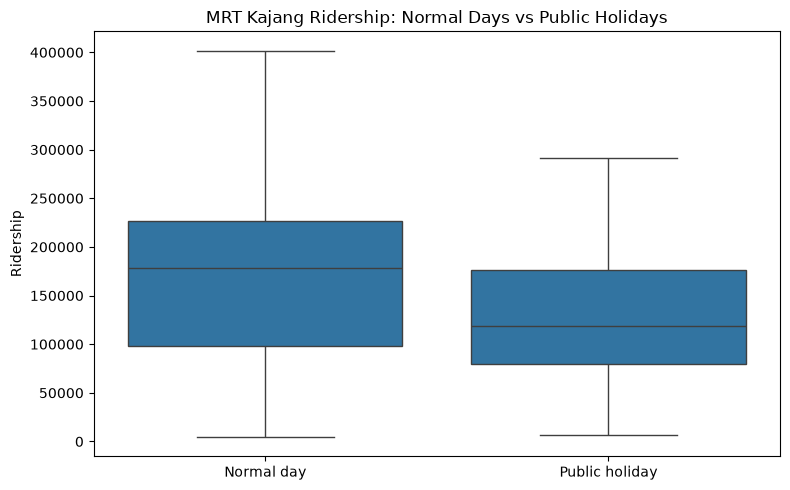

In [31]:
holiday_effect = (
    eda.groupby("is_public_holiday")[target]
    .agg(["count", "mean", "median", "std"])
)
display(holiday_effect)

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=eda,
    x="is_public_holiday",
    y=target,
    showfliers=False,
)
plt.xticks([0, 1], ["Normal day", "Public holiday"])
plt.title("MRT Kajang Ridership: Normal Days vs Public Holidays")
plt.xlabel("")
plt.ylabel("Ridership")
plt.tight_layout()
plt.show()

In [32]:
holiday_by_weekday = (
    eda.groupby(["day_of_week", "is_public_holiday"])[target]
    .median()
    .unstack()
    .reindex(weekday_order)
)

holiday_by_weekday = holiday_by_weekday.rename(
    columns={0: "Normal day", 1: "Public holiday"}
)
display(holiday_by_weekday)

is_public_holiday,Normal day,Public holiday
day_of_week,,
Monday,194195.5,113113.0
Tuesday,199957.0,89532.0
Wednesday,202776.0,158044.0
Thursday,201314.5,139344.0
Friday,210356.0,85547.5
Saturday,133697.0,123752.0
Sunday,115480.5,123836.0


## Key Findings

- The dataset contains daily observations with no missing calendar dates.
- Service histories have different starting points, producing structural missing values.
- MRT Kajang ridership has strong weekly seasonality.
- Ridership changed substantially during the 2020–2021 COVID period.
- The strongest examined lag is seven days.
- Sudden changes require investigation against holidays and movement restrictions.
- Modeling must use chronological splits rather than random train/test splitting.

## Candidate Features

- Day of week and weekend indicator
- Month and year
- Public-holiday indicator
- Lags: 1, 7, 14, and 28 days
- Rolling averages based only on previous observations
- COVID/regime indicators where justified